# Model Evaluation for Regression

In this lesson we focus on **how to evaluate regression models**. We'll compute standard **quantitative metrics** and use **visual diagnostics** to understand error structure. We'll also introduce **cross‑validation** and **learning curves** to reason about generalisation and data sufficiency.

**Learning objectives**
- Compute and interpret $\text{MSE}$, $\text{RMSE}$, $\text{MAE}$, and $R^2$ on train/test splits.
- Create residual diagnostics: residuals vs predictions, predicted vs actual, and residual histograms (plus an optional Q–Q plot).
- Use cross‑validation to obtain more stable performance estimates.
- Plot and read **learning curves**; understand under/overfitting and data needs.



## Quantitative Metrics (Theory)

Let $\{(x_i, y_i)\}_{i=1}^n$ be the dataset and $\hat{y}_i$ the model predictions.

- **Mean Squared Error (MSE)**
  $$
  \mathrm{MSE} = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2
  $$

- **Root Mean Squared Error (RMSE)** — same units as $y$:
  $$
  \mathrm{RMSE} = \sqrt{\mathrm{MSE}}
  $$

- **Mean Absolute Error (MAE)** — robust to outliers:
  $$
  \mathrm{MAE} = \frac{1}{n}\sum_{i=1}^n \lvert y_i - \hat{y}_i \rvert
  $$

- **Coefficient of Determination ($R^2$)** — variance explained:
  $$
  R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}
  $$

**Rules of thumb**
- Lower **RMSE/MAE** is better; compare across models trained on the **same** target and scale.
- Higher **$R^2$** is better; negative $R^2$ can occur on test data (worse than predicting the mean).


In [1]:
# Load Diabetes dataset, split, fit a baseline Linear Regression model
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# Data
data = load_diabetes(as_frame=True)
df = data.frame.copy()
df.rename(columns={'target': 'disease_progression'}, inplace=True)

X = df.drop(columns=['disease_progression'])
y = df['disease_progression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Baseline model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predictions
y_pred_train = linreg.predict(X_train)
y_pred_test  = linreg.predict(X_test)

# Metrics table
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test, y_pred_test)
rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred_test)

metrics_df = pd.DataFrame({
    'set': ['train', 'test'],
    'MSE': [mse_train, mse_test],
    'RMSE': [rmse_train, rmse_test],
    'MAE': [mae_train, mae_test],
    'R2': [r2_train, r2_test],
})
metrics_df


,set,MSE,RMSE,MAE,R2
0,train,2868.549703,53.558843,43.483504,0.527919
1,test,2900.193628,53.853446,42.794095,0.452603



### Reading the table
- Compare **train** vs **test**. A large gap (train much better) suggests **overfitting**; both poor suggests **underfitting** or **model misspecification**.
- Prefer **RMSE** or **MAE** for interpretability (units of the target).



## Visual Diagnostics

Residual plots help us see patterns that metrics cannot reveal.
- **Residuals vs Predicted**: check linearity and homoscedasticity.
- **Predicted vs Actual**: overall calibration (points near the diagonal are better).
- **Residual Histogram**: rough normality check (useful for inference).
- **Q–Q plot (optional)**: a more formal normality visual.


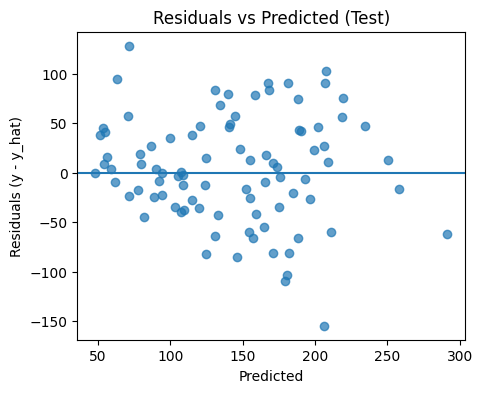

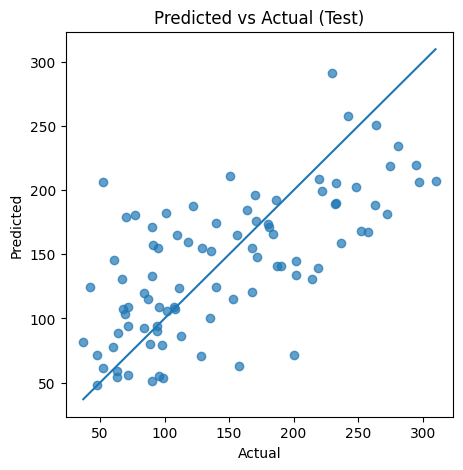

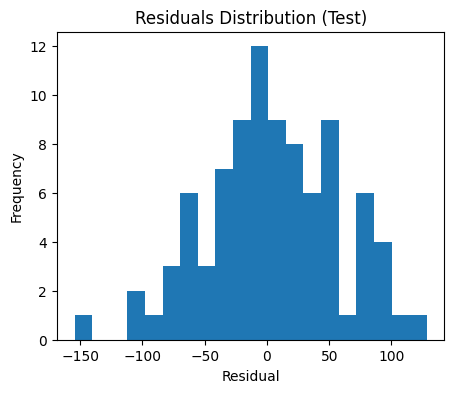

In [2]:
# Residual diagnostics
import matplotlib.pyplot as plt
import numpy as np

residuals_train = y_train - y_pred_train
residuals_test  = y_test - y_pred_test

# Residuals vs Predicted (Test)
plt.figure(figsize=(5,4))
plt.scatter(y_pred_test, residuals_test, alpha=0.7)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals (y - y_hat)")
plt.title("Residuals vs Predicted (Test)")
plt.show()

# Predicted vs Actual (Test)
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_test, alpha=0.7)
lo = min(y_test.min(), y_pred_test.min())
hi = max(y_test.max(), y_pred_test.max())
plt.plot([lo, hi], [lo, hi])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (Test)")
plt.show()

# Residual histogram (Test)
plt.figure(figsize=(5,4))
plt.hist(residuals_test, bins=20)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residuals Distribution (Test)")
plt.show()



### Optional: Q–Q Plot
A Q–Q plot compares residual quantiles to those of a normal distribution.
- Straight line $\Rightarrow$ residuals approximately normal.
- Heavy tails or curvature $\Rightarrow$ departures from normality (affects *inference* more than *prediction*).

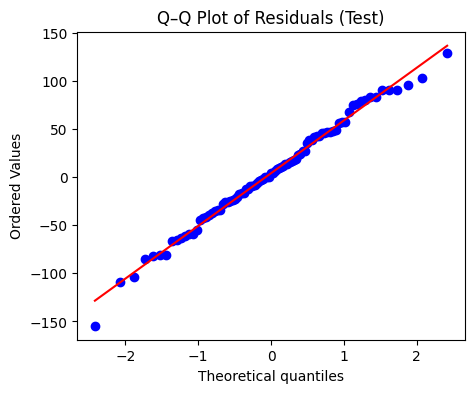

In [3]:
# Optional Q–Q plot (requires scipy). If not installed on the platform, skip this cell.
try:
    import scipy.stats as stats
    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(5,4))
    ax = fig.add_subplot(111)
    stats.probplot((y_test - y_pred_test), dist="norm", plot=ax)
    ax.set_title("Q–Q Plot of Residuals (Test)")
    plt.show()
except Exception as e:
    print("Skipping Q–Q plot (scipy likely not available in this environment):", e)



**Interpreting diagnostics**
- **Non-linearity:** Curvature in residuals vs predicted suggests the linear model is missing structure (consider trees, interactions, or basis expansions).
- **Heteroscedasticity:** Cone/funnel shapes indicate variance depends on $\hat{y}$; robust losses or transforms may help.
- **Outliers/Influential points:** Large residuals can unduly affect fit; consider robust models or inspection.



## Cross‑Validation

Train/test splits can be **noisy**. **$k$‑fold cross‑validation** averages performance across $k$ folds to reduce variance.

We'll compute cross‑validated $R^2$ and negative MSE (higher is better for $R^2$; less negative is better for MSE). Use `n_jobs=-1` to enable implicit parallelism on NCI ARE.


In [6]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
from sklearn.linear_model import LinearRegression

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2  = cross_val_score(LinearRegression(), X, y, scoring='r2', cv=cv, n_jobs=1)
cv_mse = cross_val_score(LinearRegression(), X, y, scoring='neg_mean_squared_error', cv=cv, n_jobs=1)

print("CV R^2 scores:", cv_r2)
print("Mean R^2:", np.mean(cv_r2), "±", np.std(cv_r2))
print()
print("CV neg-MSE scores:", cv_mse)
print("Mean neg-MSE:", np.mean(cv_mse), "±", np.std(cv_mse))
print("Mean RMSE (from neg-MSE):", np.sqrt(-np.mean(cv_mse)))


CV R^2 scores: [0.45260276 0.57320015 0.39144785 0.58428888 0.39081186]
Mean R^2: 0.47847030225778486 ± 0.08496746925761751

CV neg-MSE scores: [-2900.19362849 -2662.63760862 -3312.30588884 -2797.88355256
 -3403.88779293]
Mean neg-MSE: -3015.381694287271 ± 291.23979402678145
Mean RMSE (from neg-MSE): 54.91249124094873



- **Mean & spread** across folds indicate stability.
- If performance varies widely across folds, model/data are sensitive to splits (consider more data, regularisation, or different features).



## Learning Curves

**Learning curves** show training and validation performance as a function of training set size. They help diagnose:
- **High bias (underfitting):** both curves converge to a poor score.
- **High variance (overfitting):** large gap between curves that narrows with more data.


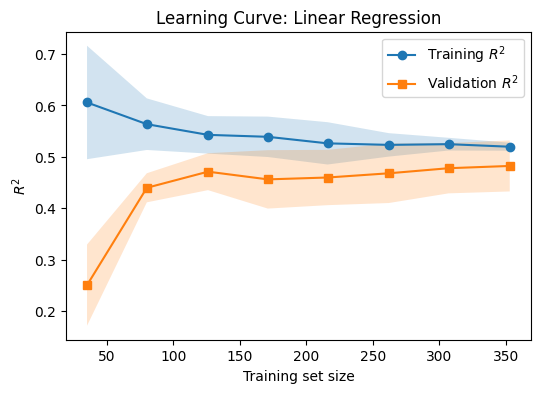

In [8]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

train_sizes, train_scores, val_scores = learning_curve(
    estimator=LinearRegression(),
    X=X, y=y,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring='r2',
    n_jobs=1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_mean, marker='o', label='Training $R^2$')
plt.plot(train_sizes, val_mean, marker='s', label='Validation $R^2$')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean-val_std,   val_mean+val_std,   alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("$R^2$")
plt.title("Learning Curve: Linear Regression")
plt.legend()
plt.show()



**Reading the curve**
- If both curves plateau at a **low** $R^2$, the model is **bias‑limited** (try richer models or features).
- If the **gap remains large**, the model is **variance‑limited** (try regularisation, more data, or ensembles).



## Summary

- Metrics ($\text{RMSE}$, $\text{MAE}$, $R^2$) quantify performance, but **diagnostic plots** reveal error structure.
- **Cross‑validation** reduces variance in performance estimates.
- **Learning curves** guide decisions about model complexity and data requirements.



## Exercises

1. **Alternative metric:** Add $R^2$ and RMSE for **training** and **test** to a single bar chart for quick comparison.
2. **Transform experiment:** Apply a log transform to the target (e.g., `np.log1p`) and re‑evaluate. Did residuals improve?
3. **Robustness check:** Use 10‑fold CV and compare the mean/variance of $R^2$ to 5‑fold. Which is more stable here?
